# ChordCutter Bot


## Dataset

[Music Bench](https://huggingface.co/datasets/amaai-lab/MusicBench)

## Idea

<strong>Input</strong>: audio file

<strong>Output</strong>: chord sheet

1. Input audio file
2. Audio file gets split into segments (ex: 10s)
3. Each segment gets passed into the NN. Outputs the chord progression and the timestamp
4. Pass the same segment into another NN that generates the lyrics and timestamps
5. Overlay the chords and lyrics based on the timestamps

### Components

1. Audio to chords NN
2. Audio to lyrics NN
3. Chord sheet assembler
4. Data preprocessor (ex: .mp3 to .wav?)


### Data Loading


In [1]:
# Libraries
import os
import torch
import requests
import tarfile
import librosa
from io import BytesIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from datasets import load_dataset

c:\Users\Sean\Documents\GitHub\ChordCutterBot\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("amaai-lab/MusicBench")
ds

DatasetDict({
    train: Dataset({
        features: ['dataset', 'location', 'main_caption', 'alt_caption', 'prompt_aug', 'prompt_ch', 'prompt_bt', 'prompt_bpm', 'prompt_key', 'beats', 'bpm', 'chords', 'chords_time', 'key', 'keyprob', 'is_audioset_eval_mcaps'],
        num_rows: 52768
    })
    test: Dataset({
        features: ['dataset', 'location', 'main_caption', 'alt_caption', 'prompt_aug', 'prompt_ch', 'prompt_bt', 'prompt_bpm', 'prompt_key', 'beats', 'bpm', 'chords', 'chords_time', 'key', 'keyprob', 'is_audioset_eval_mcaps'],
        num_rows: 800
    })
})

In [3]:
train_df = ds['train'].to_pandas()
test_df = ds['test'].to_pandas()

train_df
# test_df

# TODO: remove np.nan from chords list

,dataset,location,main_caption,alt_caption,prompt_aug,prompt_ch,prompt_bt,prompt_bpm,prompt_key,beats,bpm,chords,chords_time,key,keyprob,is_audioset_eval_mcaps
0,MusicBench,data_aug2/-0SdAVK79lg_1.wav,This mellow instrumental track showcases a dom...,This song features an electric guitar as the m...,,The chord progression in this song is E.,The beat counts to 4.,The bpm is 112.0.,The key of this song is E major.,"[[0.37212133669135816, 0.9070457581851855, 1.4...",112.0,[E],[0.5400400339790407],"[E, major]",[0.8934084177017212],False
1,MusicBench,data_aug2/-0SdAVK79lg_2.wav,This relaxing song is perfect for a coffee sho...,This song features an electric guitar as the m...,,The chord progression in this song is E.,The beat is 4.,The song is played at the pace of Vivace.,This song is in the key of E major.,"[[0.2658142022146419, 0.6479221178981897, 1.04...",157.0,[E],[0.4485947212378337],"[E, major]",[0.8934084177017212],False
2,MusicBench,data_aug2/-0SdAVK79lg_3.wav,This laid-back instrumental track is perfect f...,This song features an electric guitar as the m...,,The chord progression in this song is E.,The beat counts to 4.,The bpm is 151.0.,The key of this song is E major.,"[[0.2754422138603508, 0.6713903962846051, 1.08...",151.0,[E],[0.3861310098244245],"[E, major]",[0.8934084177017212],False
3,MusicBench,data_aug2/-0SdAVK79lg_4.wav,This is a relaxing song that features an elect...,This song features an electric guitar as the m...,,The chord progression in this song is E.,The beat is 4.,The song is played at the pace of Vivace.,This song is in the key of E major.,"[[0.2801938173601484, 0.6829724298153618, 1.10...",148.0,[E],[0.33809850513698275],"[E, major]",[0.8934084177017212],False
4,MusicBench,data_aug2/-0SdAVK79lg_5.wav,This relaxing song is perfect for a coffee sho...,This song features an electric guitar as the m...,,The chord sequence is C#.,The time signature is 4/4.,This song goes at 130.0 beats per minute.,This song is in the key of C# major.,"[[0.32, 0.78, 1.26, 1.74, 2.2, 2.66, 3.12, 3.5...",130.0,[C#],[0.33809850513698275],"[C#, major]",[0.8934084177017212],False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52763,MusicBench,data/zir3uL14ijM.wav,This mellow tune is led by a passionate male v...,The low quality recording features a passionat...,,"The chord progression in this song is E, F#m7,...",The beat is 3.,The bpm is 92.0.,This song is in the key of E major.,"[[0.02, 0.68, 1.38, 2.0, 2.66, 3.3, 3.96, 4.58...",92.0,"[E, F#m7, F#m7b5, E/B]","[0.464399092, 1.30031746, 3.90095238, 6.315827...","[E, major]",[0.8000931739807129],False
52764,MusicBench,data/zjZV0tvur2I.wav,"This song, in the key of G minor and with a te...",The low quality recording features a widely sp...,,The chord sequence is Ab7.,The beat counts to 2.,The tempo of this song is 127.0 beats per minute.,This song is in the key of G minor.,"[[0.28, 0.76, 1.22, 1.72, 2.2, 2.66, 3.16, 3.6...",127.0,[Ab7],[1.30031746],"[G, minor]",[0.7355943918228149],False
52765,MusicBench,data/zjsWFvUkh7M.wav,This Pop Rock song is led by a lively male voc...,A male vocalist sings this energetic song. The...,,"The chord sequence is D, Gm, Daug.",The beat is 3.,This song goes at 110.0 beats per minute.,The key of this song is D minor.,"[[0.02, 0.54, 1.06, 1.58, 2.12, 2.64, 3.18, 3....",110.0,"[D, Gm, Daug]","[0.557278911, 3.622312925, 8.266303854]","[D, minor]",[0.7975711822509766],True
52766,MusicBench,data/zqbHYVH6Wqo.wav,This devotional and spirited instrumental song...,The song is an instrumental. The tempo is medi...,,The chord sequence is F.,The beat is 2.,This song is played in Presto.,The key is F major.,"[[0.28, 0.6, 0.94, 1.28, 1.64, 1.98, 2.32, 2.6...",177.0,[F],[0.464399092],"[F, major]",[0.8479340076446533],False


### Chord Exploration


In [4]:
# Takes in a Series (chords column) and gives a set of unique chords
def get_chord_set(chords: pd.Series) -> set:
    return set(chords.apply(list).explode().unique())

# Returns a list of root chords; simplifies slash chords if necessary
def get_root_chords(chords) -> list:
    return map(lambda x: x.split('/')[0] if is_slash_chord(x) else x, chords)

# Filter for slash chords
def is_slash_chord(chord) -> bool:
    return chord and isinstance(chord, str) and "/" in chord

In [5]:
# Chords exploration
chords = train_df['chords']

# Set of all chords
chords_set = set(get_chord_set(chords))

# Set of all slash chords (ex: C/E)
slash_chords = set(filter(is_slash_chord, chords_set))

# Set of root chords of the slash chords (ex: C from C/E)
root_slash = set(get_root_chords(slash_chords))

# Set of (all chords - slash chords) U (root chords)
root_chords = (chords_set - slash_chords).union(root_slash)

print(f"All Chords:\tsize={len(chords_set)}, {chords_set}")
print(f"Slash Chords:\tsize={len(slash_chords)}, {slash_chords}")
print(f"Root Slash:\tsize={len(root_slash)}, {root_slash}")
print(f"Root Chords:\tsize={len(root_chords)}, {root_chords}")
# The number of root chords is the total number of chords minus the number of slash chords
# (there are no roots from slash chords that do not appear in the set of non-slash chords)

All Chords:	size=292, {'Gm7', 'C#maj7', 'Bbm7', 'G#/Gb', 'E/D', 'Cmaj7', 'C#m7b5/B', 'G/F', 'Gb7', 'N', 'Fm7b5/D#', 'G#m7', 'G#/D#', nan, 'E/G#', 'Db/B', 'Gb7/A#', 'Db6', 'Amaj7', 'Em6', 'Fm7', 'Bbm6', 'C#/G#', 'A#/G#', 'A/E', 'C#aug', 'D#/C#', 'Adim', 'A#m7', 'Cm7b5/Bb', 'G/A', 'G#m7b5', 'Am', 'D#', 'Ebm7b5', 'C#7/F', 'F#', 'Bbmaj7', 'Abm7b5', 'Db', 'C/A#', 'D7', 'Fm', 'Bb7', 'Gbm6', 'Fm6', 'C/G', 'Gb/G#', 'F', 'D#/G', 'F7/A', 'Ddim', 'Bb/Ab', 'E', 'C', 'G#/A#', 'Gm6', 'Eb/F', 'Fdim', 'D#m', 'E7/G#', 'C/Bb', 'F#m6', 'Abdim', 'Eb/G', 'D/F#', 'E6', 'C7/E', 'A#', 'Ebaug', 'Ab/D#', 'Ebm7', 'G#/C', 'Gb/A#', 'D#m6', 'A#6', 'Cm7', 'Aaug', 'C#/E#', 'C#/F', 'E/B', 'D#m7b5', 'C7', 'B/A', 'A#maj7', 'Am7', 'F/A', 'B/C#', 'Bb6', 'Am6', 'Gbaug', 'Bmaj7', 'A#7', 'B/D#', 'Db7/F', 'Gb', 'Am7b5/G', 'D#7/G', 'Db/G#', 'A#m6', 'Bbm7b5', 'Gm', 'B', 'E/F#', 'D#m7', 'D6', 'D#7', 'F#/C#', 'Abm7b5/Gb', 'Gdim', 'A#aug', 'Bbdim', 'C6', 'B/Db', 'Dbm7', 'Bm6', 'Ebdim', 'D#/F', 'Bbm', 'Em7', 'A#/F', 'Gbmaj7', 'Db/F

In [6]:
num_chord_classes = len(root_chords)
print(num_chord_classes)

172


### Audio Analysis Exploration


In [7]:
def open_audio_file(location='', num=-1):
    ''' 
    Gets the tar file online without reading everything into memory. Iterates through response one file at a time.
    Only considers files (and currently .wav files). Can be used to get a specific file, though this is achieved
    by iterating over every item in the decompressed tar file. Can also be used to get a specific number of files.

    Input
    - location: the filepath (as provided by the "Location" column in the dataset) to retrieve (note: current implementation is very inefficient). Default is the empty string, which will output all files
    - num: the number of files to retrieve, from the beginning. Default is -1, which will output all the files

    Output
    - None
    '''
    url = 'https://huggingface.co/datasets/amaai-lab/MusicBench/resolve/main/MusicBench.tar.gz'
    response = requests.get(url, stream=True)
    print("response received!")
    print(response, '\n')
    retrieved_count = 0
    
    if response.status_code == 200:
        # open tar file as a stream
        with tarfile.open(fileobj=response.raw, mode='r|gz') as tar:
            print("opened tar file!")

            for member in tar:
                # only care about files
                # if location is given, only get that file; otherwise get all files
                if member.isfile() and (member.name == f"datashare/{location}" or not location):
                    file = tar.extractfile(member)
                    print("Type:", type(file))
                    print("File:", file)
                    print(f"File name: {member.name}")

                    file = tar.extractfile(member)
                    print("Extracted file:", file, '\n')

                    # read this file into memory
                    file_bytes = BytesIO(file.read())

                    # only get audio files
                    if member.name.endswith('.wav'):
                        audio_data, sr = librosa.load(file_bytes, sr=None)

                        # metadata
                        print("-----METADATA-----")
                        print(f"Audio length: {len(audio_data)} samples, Sample Rate: {sr}")
                        print(type(audio_data), audio_data.shape)
                        print("audio_data element:", audio_data[0])

                        # sound amplitude
                        plt.plot(audio_data)
                        plt.show()

                        # Mel-frequency cepstral coefficients
                        mfccs = librosa.feature.mfcc(y=audio_data, sr=sr, n_mfcc=13)
                        plt.figure(figsize=(10, 4))
                        librosa.display.specshow(mfccs, sr=sr, x_axis='time')
                        plt.colorbar(label='MFCC')
                        plt.title('MFCCs')
                        plt.show()
                        print("MFCCs:", mfccs.shape)

                        # chroma feature extraction
                        chroma = librosa.feature.chroma_stft(y=audio_data, sr=sr)
                        print("Chroma Shape:", chroma.shape)
                        plt.figure(figsize=(10, 4))
                        librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', cmap='coolwarm', sr=sr)
                        plt.colorbar(label='Intensity')
                        plt.title('Chroma Feature Representation')
                        plt.xlabel('Time (seconds)')
                        plt.ylabel('Pitch Class')
                        plt.show()

                        # harmonic-percussive separation
                        harmonic, percussive = librosa.effects.hpss(y=audio_data)

                        plt.figure(figsize=(10, 4))
                        plt.plot(harmonic, label="Harmonic")
                        plt.plot(percussive, label="Percussive")
                        plt.legend()
                        plt.title("Harmonic & Percussive Separation")
                        plt.show()

                        # Constant-Q Transform (CQT)
                        cqt = librosa.cqt(y=audio_data, sr=sr)
                        cqt_db = librosa.amplitude_to_db(abs(cqt))
                        plt.figure(figsize=(10, 4))
                        librosa.display.specshow(cqt_db, sr=sr, x_axis='time', y_axis='cqt_note', cmap='coolwarm')
                        plt.colorbar(label='dB')
                        plt.title('Constant-Q Transform (CQT)')
                        plt.show()

                    file.close()
                    if location:  # stop after finding requested file
                        break
                    else:
                        retrieved_count += 1
                        if retrieved_count == num:
                            break
    else:
        print(f"Failed to download the file: {response.status_code}")

response received!
<Response [200]> 

opened tar file!
Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name=''>
File name: datashare/data_aug2/u3yOMK8SuRI_1.wav
Extracted file: <ExFileObject name=''> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.0


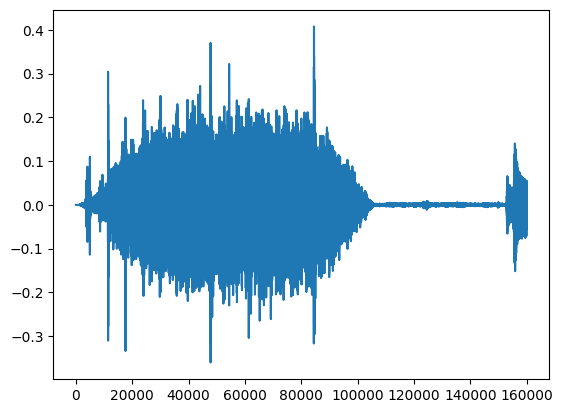

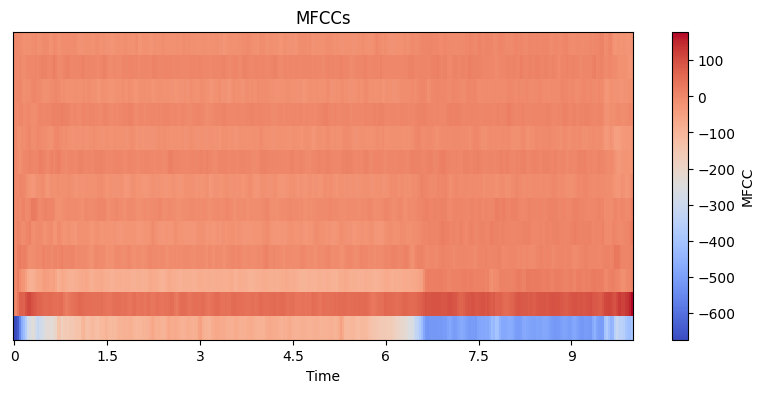

MFCCs: (13, 313)
Chroma Shape: (12, 313)


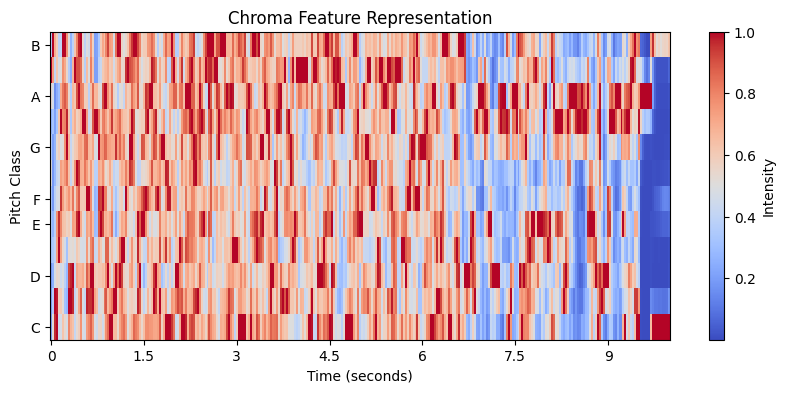

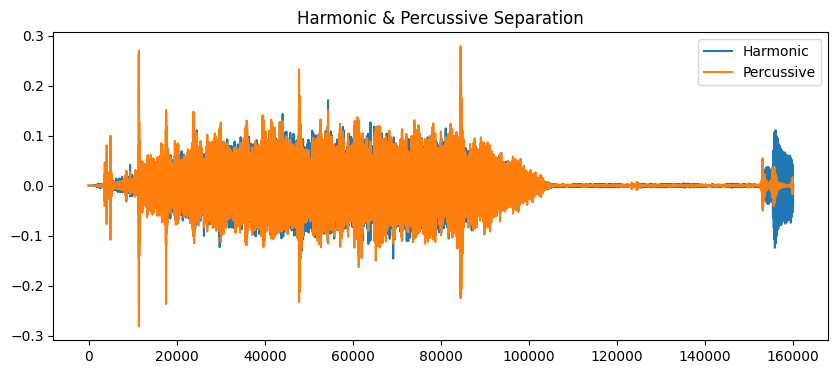

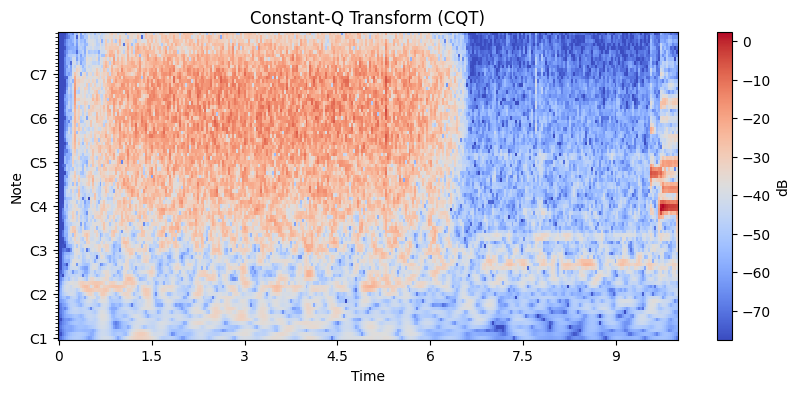

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name=''>
File name: datashare/data_aug2/4a1a-lmDVaY_11.wav
Extracted file: <ExFileObject name=''> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.0024597168


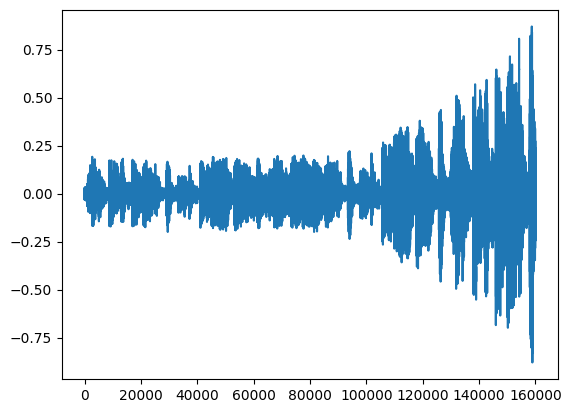

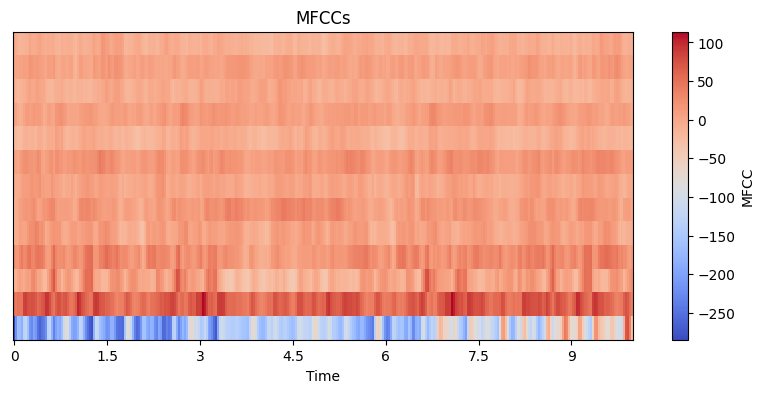

MFCCs: (13, 313)
Chroma Shape: (12, 313)


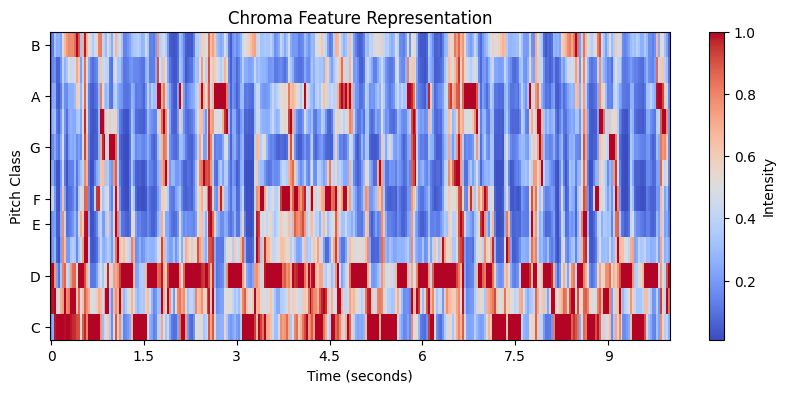

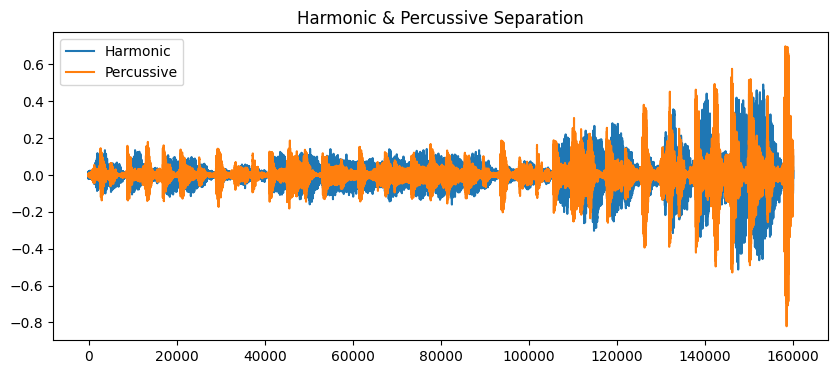

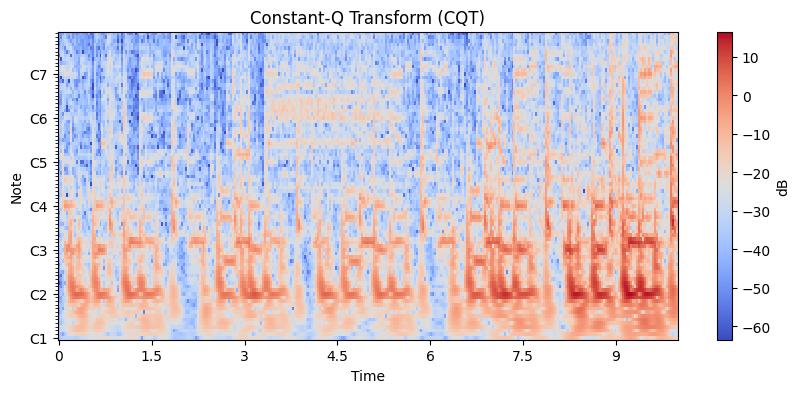

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name=''>
File name: datashare/data_aug2/rE7S4nLrThs_5.wav
Extracted file: <ExFileObject name=''> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: -0.031066895


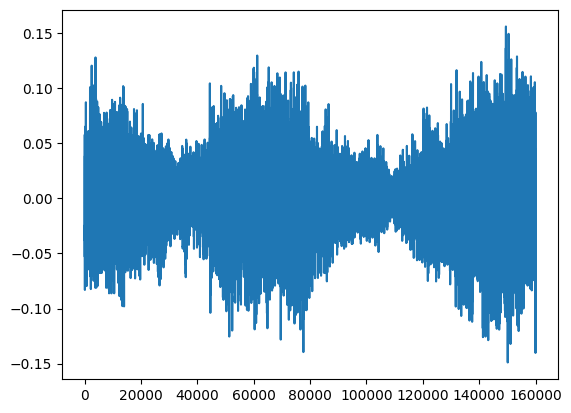

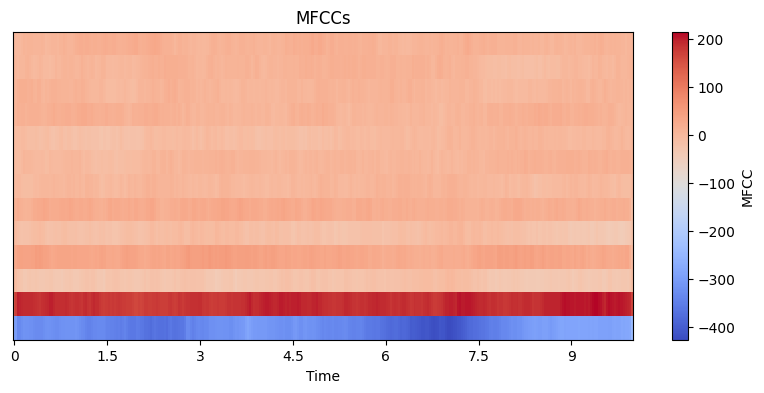

MFCCs: (13, 313)
Chroma Shape: (12, 313)


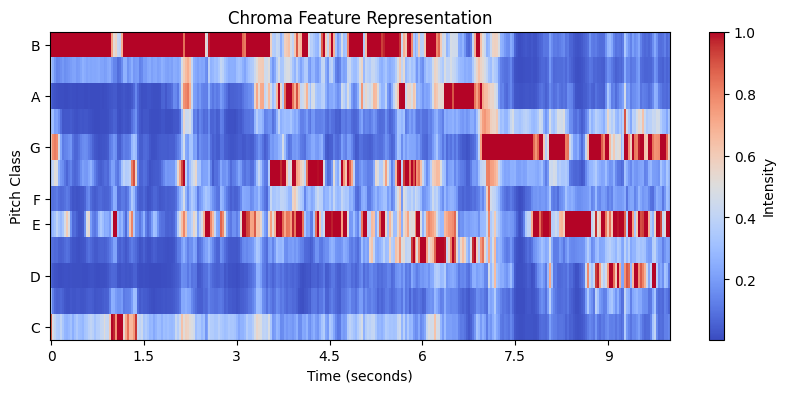

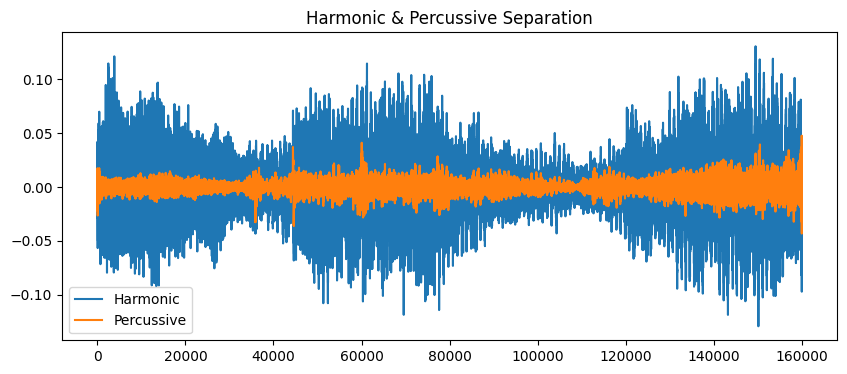

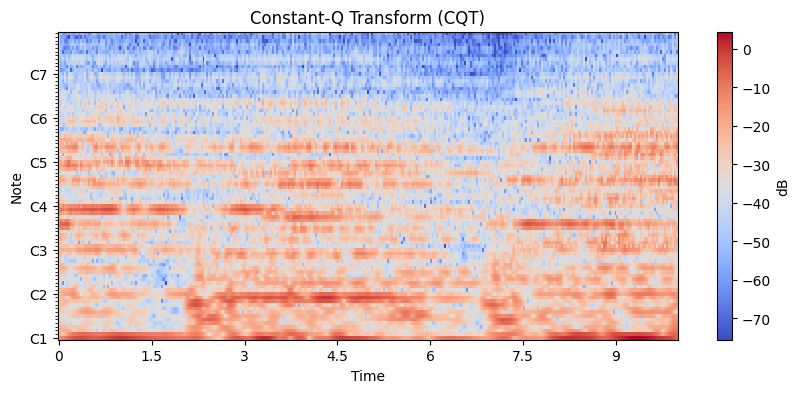

In [8]:
# get specific number of audio files
open_audio_file(num=3)

response received!
<Response [200]> 

opened tar file!
Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name=''>
File name: datashare/data_aug2/u3yOMK8SuRI_1.wav
Extracted file: <ExFileObject name=''> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.0


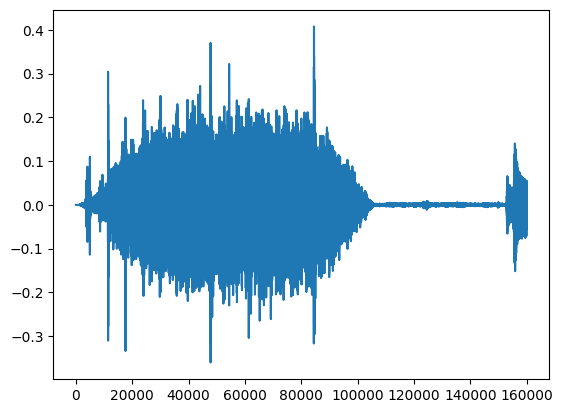

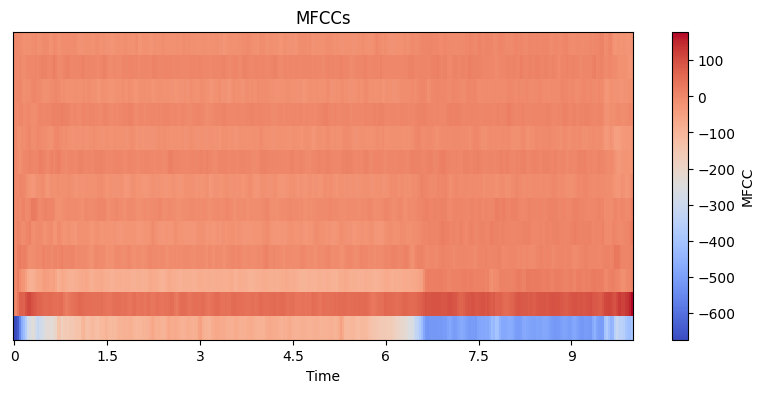

MFCCs: (13, 313)
Chroma Shape: (12, 313)


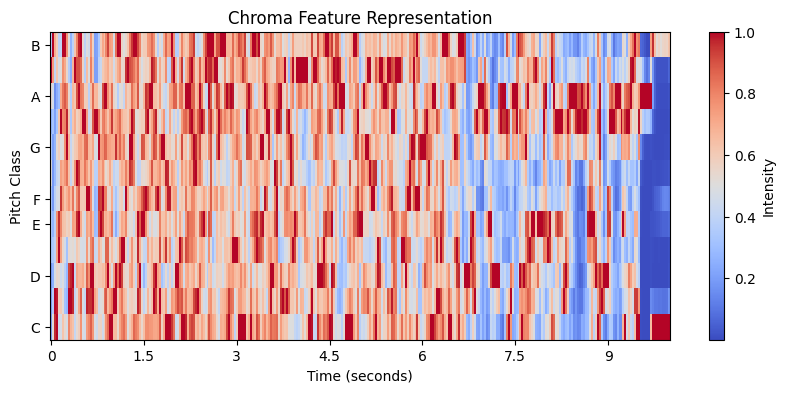

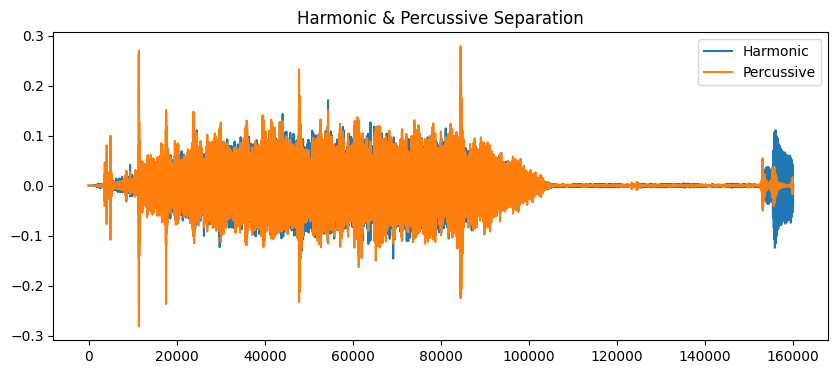

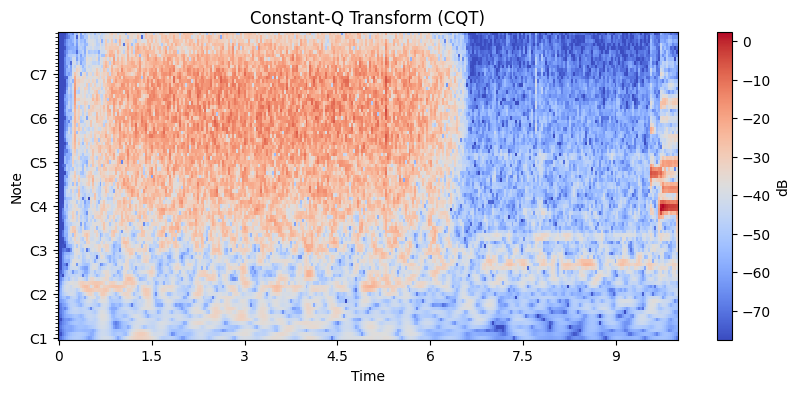

In [9]:
# get audio file by location (see table)
open_audio_file("data_aug2/u3yOMK8SuRI_1.wav")

### Chroma Features Preprocessing


In [10]:
def compute_and_save_chromas(audio_paths, output_dir, sr=None):
    """
    For each filepath in audio_paths:
      - compute chroma
      - save as .npy in output_dir
    """
    os.makedirs(output_dir, exist_ok=True)
    for audio_path in audio_paths:
        # 1) Load the audio
        audio_data, sr_ = librosa.load('datashare/' + audio_path, sr=sr)
        audio_data = librosa.util.normalize(audio_data)

        # 2) Compute chroma (Shape: (12, time_frames))
        chroma_features = librosa.feature.chroma_stft(y=audio_data, sr=sr_)
        # Normalize or scale if you want
        chroma_features /= np.max(chroma_features)

        # 3) Save .npy
        #    e.g. if audio_path = "/path/to/audio/song.wav"
        #    you'll get output_dir + "song.npy"
        filename_stem = os.path.splitext(os.path.basename(audio_path))[0]
        out_path = os.path.join(output_dir, filename_stem + ".npz")
        np.savez(out_path, chroma=chroma_features, sr=sr_)

        # 4) Save sr

    print("Precomputation complete!")

In [11]:
# compute_and_save_chromas(train_df['location'], "chroma_features")

## Library Functions

#### Tokenizing


In [12]:
# Preprocessing - Tokenizing
idx_to_chord = list(root_chords)  # mapping of index-to-chords
idx_to_chord = ['<PAD>', '<NULL>'] + idx_to_chord
chord_to_idx = {chord: i for i, chord in enumerate(idx_to_chord)}
print("idx_to_chord:\t", idx_to_chord)
print("chord_to_idx:\t", chord_to_idx)

idx_to_chord:	 ['<PAD>', '<NULL>', 'Gm7', 'Gbdim', 'C#maj7', 'Bbm7', 'Cmaj7', 'Db7', 'Gb7', 'N', 'Gbm7', 'G#m7', nan, 'Db6', 'Amaj7', 'Em6', 'Fm7', 'Bbm6', 'A', 'E7', 'Baug', 'G#', 'C#aug', 'A#m7b5', 'Fm7b5', 'Adim', 'A#m7', 'Gmaj7', 'G#m7b5', 'Am', 'C#m7b5', 'D#', 'Ebm7b5', 'F#', 'Bbmaj7', 'Em7b5', 'Eb', 'Abm7b5', 'Db', 'B7', 'D7', 'Fm', 'Bb7', 'A#dim', 'C#6', 'F6', 'Gbm6', 'Bb', 'Fm6', 'Faug', 'Em', 'F', 'Eaug', 'Ddim', 'F#m', 'E', 'C', 'Gm6', 'F#7', 'Gm7b5', 'Fdim', 'Ebm6', 'D#m', 'F#maj7', 'Bbaug', 'Dm7', 'Fmaj7', 'Abm7', 'F#m6', 'Abdim', 'C#m6', 'Ab7', 'E6', 'Bm', 'C#m', 'G#m', 'A#', 'Ebaug', 'A#m', 'Ebm7', 'B6', 'Gaug', 'Dm', 'C#7', 'D#aug', 'D#m6', 'Cdim', 'A#6', 'Cm7', 'Aaug', 'G#7', 'Abm6', 'Abmaj7', 'Am7b5', 'D#m7b5', 'C7', 'Gbm7b5', 'F#m7b5', 'A#maj7', 'Am7', 'Dbm6', 'C#m7', 'F#m7', 'Bb6', 'C#dim', 'Am6', 'Gbaug', 'Bmaj7', 'Dbaug', 'A#7', 'D#maj7', 'Gb', 'A#m6', 'Bbm7b5', 'G', 'Gm', 'B', 'D#m7', 'D6', 'D#7', 'Gdim', 'A#aug', 'Bbdim', 'C6', 'G#m6', 'G#maj7', 'G7', 'Dbm7b5', '

### Functions

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("mps")

# given list of chord indices and the time of their occurence,
# return a list of chord indices for each time frame
def get_chords_per_frame(chords:list, chord_times:list, num_frames:int, hop_length=512, sr=22050) -> list:
    res = []
    j = 0
    chord = -1
    for i in range(num_frames):
        seconds = frame_to_time(i, hop_length, sr)

        # update the chord if there are more chords and
        # the time frame is in the next chord
        if j < len(chord_times) and seconds >= chord_times[j]:
            chord = chords[j]
            j += 1
        res.append(chord)
    return res

# converts timeframe to time in seconds
def frame_to_time(frame_idx:int, hop_length=512, sr=22050) -> float:
    return (frame_idx * hop_length) / sr

# takes pd.Series of chord progressions, returns a list of token indices
def tokenize_chord_labels(chord_labels: pd.Series) -> list:
    root_chord_labels = [list(get_root_chords(label)) for label in chord_labels]
    root_chord_idx = [chord_labels_to_idx(root_labels) for root_labels in root_chord_labels]
    print("Chord indices:", root_chord_idx)
    return root_chord_idx

# helper function to convert one chord progression to a list of token indices
def chord_labels_to_idx(chord_labels: list) -> list:
    return [chord_to_idx[label] for label in chord_labels]

def chroma_extraction(file):
    with open(file, "rb") as file_bytes:
        # load and normalize audio file
        audio_data, sr = librosa.load(file, sr=None)
        audio_data = librosa.util.normalize(audio_data)

        # get chroma features (12, T) where T=frames
        chroma_features = librosa.feature.chroma_stft(y=audio_data, sr=sr)
        chroma_features /= np.max(chroma_features)  # scale [0, 1]

        chroma_tensor = torch.tensor(chroma_features, dtype=torch.float32).to(device)
        return chroma_tensor, chroma_tensor.shape[1], sr  # Shape=(12, sequence_length, sr)
    

# takes chord indices (argmax of model output),
# returns a collapsed list of the chords and their times
def process_chord_progression(chord_idx, sr=22050):
    chords = []
    times = []
    prev = float("-inf")
    for frame_idx, idx in enumerate(chord_idx):
        if idx != prev:
            chords.append(idx_to_chord[idx])
            times.append(frame_to_time(frame_idx, sr=sr))
            prev = idx
    
    return chords, times

# load checkpoint to model and optimizer
def load_checkpoint(model, opt, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])
    opt.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    previous_loss = checkpoint['loss']
    return model, opt, start_epoch, previous_loss

### Dataset and Dataloader

In [14]:
class ChromaDataset(TensorDataset):
    def __init__(self, filepaths, chord_labels, chord_times, npy_dir, device):
        self.filepaths = filepaths
        self.chord_labels = tokenize_chord_labels(chord_labels)
        self.chord_times = chord_times
        self.npy_dir = npy_dir
        self.device = device
    
    def __len__(self):
        return len(self.filepaths)
    
    def __getitem__(self, i):
        filepath = self.filepaths[i]
        filename_stem = os.path.splitext(os.path.basename(filepath))[0]

        # Load the precomputed chroma
        npz_path = os.path.join(self.npy_dir, filename_stem + ".npz")
        npz_data = np.load(npz_path)  
        chroma_features = npz_data['chroma']  # shape: (12, time_frames)
        sr = int(npz_data['sr'])  # ex: 160000

        # Convert to PyTorch tensor
        chroma_tensor = torch.tensor(chroma_features, dtype=torch.float32).to(self.device)
        seq_len = chroma_tensor.shape[1]  # time_frames

        timeframes = chroma_features.shape[1]
        chord_sequence = get_chords_per_frame(self.chord_labels[i], self.chord_times[i], timeframes, sr=sr)
        chord_sequence = torch.tensor(chord_sequence, dtype=torch.long).to(self.device)

        return chroma_tensor.T, chord_sequence  # shape: (seq_len, 12), (seq_len,)

# Used in Dataloader
def collate_fn(batch):
    sequences, labels = zip(*batch)  # batch = list of tuples (chroma_features, chord_labels) --> ((seq_length, 12), (seq_length,))

    # OG sequence lengths
    lengths = torch.tensor([seq.shape[0] for seq in sequences], dtype=torch.int64, device=device)

    # sort sequence by descending length for LSTM packing
    sorted_indices = torch.argsort(lengths, descending=True)
    sequences = [sequences[i] for i in sorted_indices]
    labels = [labels[i] for i in sorted_indices]
    lengths = lengths[sorted_indices]

    # pad sequences to be stacked in batch
    padded_sequences = nn.utils.rnn.pad_sequence(sequences, batch_first=True).to(device)
    padded_labels = nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value=chord_to_idx['<PAD>']).to(device)

    # pack sequences for LSTM
    packed_sequences = nn.utils.rnn.pack_padded_sequence(padded_sequences, lengths.cpu(), batch_first=True, enforce_sorted=True).to(device)
    packed_labels = nn.utils.rnn.pack_padded_sequence(padded_labels, lengths.cpu(), batch_first=True, enforce_sorted=True).to(device)

    return packed_sequences, packed_labels, lengths

## Proof of Concept - Simple RNN


### LSTM for Chroma Features


#### Model Class Definitions


In [15]:
class AudioLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(AudioLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(in_features=hidden_dim, out_features=output_dim)

    def forward(self, x):
        packed_output, _ = self.lstm(x)  # run LSTM layer
        output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        return self.fc(output)  

#### Training

In [16]:
# mock_df = train_df.iloc[0:101]
mock_df = train_df
mock_input_files = "./datashare/" + mock_df["location"]

chroma_ds = ChromaDataset(filepaths=mock_input_files, chord_labels=mock_df['chords'], chord_times=mock_df['chords_time'], npy_dir='chroma_features', device=device)
dataloader = DataLoader(chroma_ds, batch_size=1024, shuffle=True, collate_fn=collate_fn)

packed_sequences, packed_labels, lengths = next(iter(dataloader))
packed_sequences, packed_labels, lengths = packed_sequences.to(device), packed_labels.to(device), lengths.to(device)
print("Packed sequences:", packed_sequences.data.shape)
print("Packed labels:", packed_labels.data.shape)  
print("Sequence lengths:", lengths)

Chord indices: [[27], [27], [27], [27], [83], [89], [36], [140], [64], [41], [27], [145, 27, 166, 104, 78], [145, 27, 166, 104, 78], [145, 27, 166, 104, 78], [145, 27, 166, 104, 78], [136, 83, 63, 86, 64], [53, 89, 8, 78, 41], [15, 36, 25, 6, 86], [57, 140, 121, 20, 6], [12, 64, 35, 83, 104], [153, 41, 118, 89, 20], [145, 27, 166, 104, 78], [20], [20], [20], [20], [78], [6], [104], [83], [89], [36], [20], [41, 47, 153, 169], [41, 47, 153, 169], [41, 47, 153, 169], [41, 47, 153, 169], [27, 21, 145, 88], [140, 45, 57, 61], [64, 168, 12, 67], [86, 31, 75, 22], [78, 94, 3, 102], [6, 17, 159, 149], [41, 47, 153, 169], [124, 103, 126, 80], [124, 103, 126, 80], [124, 103, 126, 80], [124, 103, 126, 80], [20, 105, 71, 41], [116, 135, 10, 119], [89, 155, 37, 78], [27, 170, 21, 104], [140, 74, 45, 20], [138, 171, 168, 116], [124, 103, 126, 80], [102, 20], [102, 20], [102, 20], [102, 20], [67, 78], [169, 6], [22, 104], [149, 83], [156, 89], [40, 36], [102, 20], [83, 118, 83, 59], [83, 118, 83, 59]

In [17]:
input_dim = 12  # Chroma feature dimensions (12, 313) --> 12 pitches
hidden_dim = 128  # hyperparameter
output_dim = 174  # Number of Chords: 172 + <PAD> + <NULL>
num_layers = 2

lstm_model = AudioLSTM(input_dim, hidden_dim, output_dim, num_layers).to(device)
print(lstm_model)

AudioLSTM(
  (lstm): LSTM(12, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=174, bias=True)
)


In [18]:
# HYPERPARAMETERS
lr = 0.001
regularization = 0.0001
loss_fn = nn.CrossEntropyLoss(ignore_index=chord_to_idx['<PAD>']).to(device)
opt = torch.optim.Adam(lstm_model.parameters(), lr=lr, weight_decay=regularization)
start_epoch = 0
epochs = 19

checkpoint_path = 'checkpoints/simple_rnn_16.pt'
checkpoint = torch.load(checkpoint_path, map_location=device)

lstm_model.load_state_dict(checkpoint['model_state_dict'])
opt.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch'] + 1
previous_loss = checkpoint['loss']

In [19]:
for epoch in range(start_epoch, epochs):
    epoch_loss = 0
    for batch_idx, (packed_batch, packed_labels, lengths) in enumerate(dataloader):
        lstm_model.train()
        packed_batch, packed_labels, lengths = packed_batch.to(device), packed_labels.to(device), lengths.to(device)

        opt.zero_grad()
        outputs = lstm_model(packed_batch)
        
        # Unpack labels
        labels, _ = nn.utils.rnn.pad_packed_sequence(packed_labels, batch_first=True, padding_value=-1)

        # Flatten outputs and labels
        outputs = outputs.view(-1, output_dim)
        labels = labels.reshape(-1)
        # print(outputs.shape)
        # print(labels.shape)

        # Calculate loss, ignoring padded time steps
        mask = (labels != -1)
        loss = loss_fn(outputs[mask], labels[mask])
        epoch_loss += loss.item()

        loss.backward()
        opt.step()

        if not batch_idx % 100: # print every 100 batches, about 25 times per epoch
            print(f'Epoch {epoch + 1}, batch {batch_idx + 1}, Average Loss: {epoch_loss/(batch_idx+1):.7f}')
    print(f'Epoch {epoch + 1}, Total Epoch Loss: {epoch_loss:.7f}')

    # -- SAVE CHECKPOINT --
    checkpoint_path = f"checkpoints/simple_rnn_{epoch+1}.pt"
    torch.save({
        'epoch': epoch,
        'model_state_dict': lstm_model.state_dict(),
        'optimizer_state_dict': opt.state_dict(),
        'loss': epoch_loss
    }, checkpoint_path)

Epoch 17, batch 1, Average Loss: 8.0744314


KeyboardInterrupt: 

#### Testing

In [20]:
# TODO: find sample rate (sr) for true labels
# TODO: implement test validation
times = 1
for sequences, labels, _ in dataloader:
    out = lstm_model(sequences)
    out_idx = out.argmax(axis=-1)
    out_chords = [[idx_to_chord[i] for i in out_idx[j]] for j in range(len(out_idx))]
    label_chords = [idx_to_chord[i] for i in labels.data]

    if not times:
        print(torch.argmax(out[0][0]))
        print("Model output shape:", out.shape)
        print("Modle idx shape:", out_idx.shape)
        print("Label shape:", labels.data.shape)
        # print("Max classes (indices) per frame:", out_idx)
        print("Max classes (chord) per frame:", out_chords)
        print("Labels:", label_chords)
        print()

        chord_progression, chord_times = process_chord_progression(out_idx[0], 16000)
        print("Chord Progression:", chord_progression)
        # print("Chord Times:", chord_times)
        label_progression, label_times = process_chord_progression(labels.data.tolist(), 16000)
        print("Label Progression:", label_progression)
        # print("Label Times:", label_times)
        break

    times -= 1

tensor(14)
Model output shape: torch.Size([1024, 313, 174])
Modle idx shape: torch.Size([1024, 313])
Label shape: torch.Size([314465])
Max classes (chord) per frame: [[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 'F#maj7', 'F#maj7', 'F#maj7', 'F#maj7', 'F#maj7', 'F#maj7', 'F#maj7', 'F#maj7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'Dm7', 'F#maj7', 'Dm7', 'Dm7', 'F#maj7', 'F#maj7', 'F#maj7', 'F#maj7', 'F#maj7', 'F#maj7', 'F#maj7', 'F#maj7', 'F#maj7', 'F

### Bidirectional LSTM

Bidirectional LSTM instead of normal LSTM, 4 layers instead of 2, 256 hidden dims instead of 128, layer normalization, dropout = 0.2

#### Model Class Definition

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("mps")

class AudioBiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout):
        super(AudioBiLSTM, self).__init__()
        # Bidirectional LSTM
        self.lstm = nn.LSTM(input_size=input_dim,
                            hidden_size=hidden_dim,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout,
                            bidirectional=True)
        # Layer Normalization
        self.layernorm = nn.LayerNorm(hidden_dim * 2)
        # Fully Connected Layer
        self.fc = nn.Linear(in_features=hidden_dim * 2, out_features=output_dim)

    def forward(self, x):
        packed_output, _ = self.lstm(x)  # run LSTM layer
        output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        output_normalized = self.layernorm(output)
        return self.fc(output_normalized)  

#### Training

In [17]:
input_files = "./datashare/" + train_df["location"]

chroma_ds = ChromaDataset(filepaths=input_files, chord_labels=train_df['chords'], chord_times=train_df['chords_time'], npy_dir='chroma_features', device=device)
dataloader = DataLoader(chroma_ds, batch_size=256, shuffle=True, collate_fn=collate_fn)

packed_sequences, packed_labels, lengths = next(iter(dataloader))
packed_sequences, packed_labels, lengths = packed_sequences.to(device), packed_labels.to(device), lengths.to(device)
print("Packed sequences:", packed_sequences.data.shape)
print("Packed labels:", packed_labels.data.shape)  
print("Sequence lengths:", lengths)

Chord indices: [[55], [55], [55], [55], [165], [155], [31], [51], [33], [114], [55], [29, 55, 4, 116, 18], [29, 55, 4, 116, 18], [29, 55, 4, 116, 18], [29, 55, 4, 116, 18], [54, 165, 98, 21, 33], [115, 155, 107, 18, 114], [75, 31, 6, 76, 21], [78, 51, 129, 56, 76], [73, 33, 110, 165, 116], [142, 114, 159, 155, 56], [29, 55, 4, 116, 18], [56], [56], [56], [56], [18], [76], [116], [165], [155], [31], [56], [114, 146, 142, 145], [114, 146, 142, 145], [114, 146, 142, 145], [114, 146, 142, 145], [55, 58, 29, 45], [51, 126, 78, 130], [33, 90, 73, 156], [21, 109, 74, 135], [18, 39, 82, 103], [76, 95, 62, 80], [114, 146, 142, 145], [36, 88, 150, 47], [36, 88, 150, 47], [36, 88, 150, 47], [36, 88, 150, 47], [56, 99, 40, 114], [38, 26, 119, 167], [155, 140, 19, 18], [55, 101, 58, 116], [51, 65, 126, 56], [111, 117, 90, 38], [36, 88, 150, 47], [103, 56], [103, 56], [103, 56], [103, 56], [156, 18], [145, 76], [135, 116], [80, 165], [123, 155], [13, 31], [103, 56], [165, 159, 165, 137], [165, 159, 

In [18]:
input_dim = 12  # Chroma feature dimensions (12, 313) --> 12 pitches
hidden_dim = 256  # hyperparameter
output_dim = 174  # Number of Chords: 172 + <PAD> + <NULL>
num_layers = 3
dropout = 0.2

bilstm_model = AudioBiLSTM(input_dim, hidden_dim, output_dim, num_layers, dropout).to(device)
print(bilstm_model)

AudioBiLSTM(
  (lstm): LSTM(12, 256, num_layers=3, batch_first=True, dropout=0.2, bidirectional=True)
  (layernorm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=512, out_features=174, bias=True)
)


In [19]:
# HYPERPARAMETERS
lr = 0.001
regularization = 0.0001
loss_fn = nn.CrossEntropyLoss(ignore_index=chord_to_idx['<PAD>']).to(device)
opt = torch.optim.Adam(bilstm_model.parameters(), lr=lr, weight_decay=regularization)
start_epoch = 0
epochs = 10

# checkpoint_path = 'checkpoints/bidirectional_lstm_1.pt'
# checkpoint = torch.load(checkpoint_path, map_location=device)

# bilstm_model.load_state_dict(checkpoint['model_state_dict'])
# opt.load_state_dict(checkpoint['optimizer_state_dict'])
# start_epoch = checkpoint['epoch'] + 1
# previous_loss = checkpoint['loss']

In [ ]:
for epoch in range(start_epoch, epochs):
    epoch_loss = 0
    for batch_idx, (packed_batch, packed_labels, lengths) in enumerate(dataloader):
        bilstm_model.train()
        packed_batch, packed_labels, lengths = packed_batch.to(device), packed_labels.to(device), lengths.to(device)

        opt.zero_grad()
        outputs = bilstm_model(packed_batch)
        
        # Unpack labels
        labels, _ = nn.utils.rnn.pad_packed_sequence(packed_labels, batch_first=True, padding_value=-1)

        # Flatten outputs and labels
        outputs = outputs.view(-1, output_dim)
        labels = labels.reshape(-1)
        # print(outputs.shape)
        # print(labels.shape)

        # Calculate loss, ignoring padded time steps
        mask = (labels != -1)
        loss = loss_fn(outputs[mask], labels[mask])
        epoch_loss += loss.item()

        loss.backward()
        opt.step()

        if not batch_idx % 10: # print every 10 batches, about 250 times per epoch
            print(f'Epoch {epoch + 1}, batch {batch_idx + 1}, Average Loss: {epoch_loss/(batch_idx+1):.7f}')
    print(f'Epoch {epoch + 1}, Total Epoch Loss: {epoch_loss:.7f}')

    # -- SAVE CHECKPOINT --
    checkpoint_path = f"checkpoints/bidirectional_lstm_{epoch+1}.pt"
    torch.save({
        'epoch': epoch,
        'model_state_dict': bilstm_model.state_dict(),
        'optimizer_state_dict': opt.state_dict(),
        'loss': epoch_loss
    }, checkpoint_path)

Epoch 1, batch 1, Average Loss: 5.3153887
Epoch 1, batch 11, Average Loss: 4.6195417
Epoch 1, batch 21, Average Loss: 4.3943313
Epoch 1, batch 31, Average Loss: 4.1722787
Epoch 1, batch 41, Average Loss: 3.9973737
Epoch 1, batch 51, Average Loss: 3.8817113
Epoch 1, batch 61, Average Loss: 3.7890259
Epoch 1, batch 71, Average Loss: 3.7072775
Epoch 1, batch 81, Average Loss: 3.6394394
Epoch 1, batch 91, Average Loss: 3.5887278
Epoch 1, batch 101, Average Loss: 3.5454309
Epoch 1, batch 111, Average Loss: 3.5062952
Epoch 1, batch 121, Average Loss: 3.4739190
Epoch 1, batch 131, Average Loss: 3.4429043
Epoch 1, batch 141, Average Loss: 3.4107505
Epoch 1, batch 151, Average Loss: 3.3858278
Epoch 1, batch 161, Average Loss: 3.3591073
Epoch 1, batch 171, Average Loss: 3.3349332
Epoch 1, batch 181, Average Loss: 3.3158673
Epoch 1, batch 191, Average Loss: 3.2975796
Epoch 1, batch 201, Average Loss: 3.2803937
Epoch 1, Total Epoch Loss: 677.2549074
Epoch 2, batch 1, Average Loss: 2.9797411
Epoch 

#### Testing

In [ ]:
times = 1
for sequences, labels, _ in dataloader:
    out = bilstm_model(sequences)
    out_idx = out.argmax(axis=-1)
    out_chords = [[idx_to_chord[i] for i in out_idx[j]] for j in range(len(out_idx))]
    label_chords = [idx_to_chord[i] for i in labels.data]

    if not times:
        print(torch.argmax(out[0][0]))
        print("Model output shape:", out.shape)
        print("Modle idx shape:", out_idx.shape)
        print("Label shape:", labels.data.shape)
        # print("Max classes (indices) per frame:", out_idx)
        print("Max classes (chord) per frame:", out_chords)
        print("Labels:", label_chords)
        print()

        chord_progression, chord_times = process_chord_progression(out_idx[0], 16000)
        print("Chord Progression:", chord_progression)
        # print("Chord Times:", chord_times)
        label_progression, label_times = process_chord_progression(labels.data.tolist(), 16000)
        print("Label Progression:", label_progression)
        # print("Label Times:", label_times)
        break

    times -= 1

### Transformer